# Build database of spatial footprints for input CSDA Program Evaluation Imagery

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | Innovation Lab ; NASA Goddard Space Flight Center | Nov. 2025 |

In [1]:
pip install matplotlib_scalebar

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import pandas as pd
from urllib.parse import quote
import numpy as np
import os, sys

sys.path.append('/home/pmontesa/code/geoscitools')
import footprintlib

sys.path.append('/home/pmontesa/code/csda_summaries/lib')
import csdalib 
#import footprintlib

import re
import fiona
import math
import glob
import rasterio

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import contextily as ctx
import random
import folium
from folium import plugins
import importlib

from multiprocessing import Pool
from functools import partial

import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter, MonthLocator, WeekdayLocator

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3

In [4]:
import geopandas as gpd
import pandas as pd

from urllib.parse import quote
import importlib
import numpy as np
import os, sys
import glob

sys.path.append('/home/pmontesa/code/geoscitools')
import footprintlib

sys.path.append('/home/pmontesa/code/csda_summaries/lib')
import csdalib 

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

## CSDA Database

In [5]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'

### Requested Acquisitions

In [6]:
SHEET_NAME = 'Requested Acquisitions' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    requested_acqs = pd.read_csv(url)
    requested_acqs = requested_acqs.drop(columns=[col for col in requested_acqs.columns if 'Unnamed:' in col])
    requested_acqs['Site'] = requested_acqs['Site'].str.rstrip()
    
except Exception as e:
    print(f"An error occurred: {e}")

print(f"{len(requested_acqs)} rows; {requested_acqs['Acquisitions Requested'].sum()} requests in total")
requested_acqs.Site.unique()

77 rows; 336 requests in total


array(['La Crau', 'Piedmont', 'Gobabeb', 'Railroad Valley',
       'Salon-de-Provence', 'PICS Libya-4', 'PICS Algeria-3', 'London',
       'Boston', 'Shadnagar', 'Melbourne', 'WLEF', 'Valencia',
       'Suramadu Bridge', 'Navarre Causway', 'Albuquerque', 'Hothot',
       'Cuprite', 'Cape Town', 'King Fahd Causeway', 'Caspian Sea',
       'Crater Lake', 'Old Bahia Br', 'Baotou', 'Sapporo', 'Casablanca',
       'Belo Horizonte'], dtype=object)

### Evaluation Sites

In [7]:
# SHEET_NAME = 'Evaluation Sites' # The name of the specific tab

# # 2. Encode the sheet name for safe use in a URL
# ENCODED_SHEET_NAME = quote(SHEET_NAME)

# # 3. Construct the full URL using the gviz/tq endpoint
# url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# # 4. Use pandas to read the CSV data directly from the URL
# try:
#     sites = pd.read_csv(url)
#     sites['Site Name'] = sites['Site Name'].str.rstrip()
#     #sites = sites[sites['Site Name'] != 'Sicily'] # Sicily site is same as Catania
    
# except Exception as e:
#     print(f"An error occurred: {e}")

# sites = sites[sites["Priority Level"] != 'unknown']
# sites.shape

In [8]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [9]:
# BUF_KM = 10
# sites_gdf = gpd.GeoDataFrame(
#         sites,
#         geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
#         crs="EPSG:4326"
#     )
# # Buffer and drop empty geoms
# sites_gdf = csdalib.buffer_site_gdf(sites_gdf, BUF_KM)
# sites_gdf = sites_gdf[~sites_gdf.geometry.is_empty]

# # Get the list of columns to drop
# cols_to_drop = sites_gdf.columns[sites_gdf.columns.str.contains('Unnamed')]
# sites_gdf = sites_gdf.drop(columns=cols_to_drop)



# print(f'{sites_gdf.shape[0]} sites in CSDA Evaluation Sites Database (site lat/lon buffered by {BUF_KM} km)')

## Read sites GeoJson
best to work downstream of this notebook that creates a GeoJSON AOI of our sites

In [10]:
csda_sites_fn = f'/explore/nobackup/projects/CSDA_eval/sites/csda_sites_aoi.geojson'

In [11]:
sites_gdf = gpd.read_file(csda_sites_fn)

In [12]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 25
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY #+ BUF_KM

In [13]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

## Build list of files to footprint

In [14]:
# Get today's date as a pandas Timestamp object
today_timestamp = pd.Timestamp.today()

# Convert the Timestamp object to a string in a specific format (e.g., YYYY-MM-DD)
today_date_string = today_timestamp.strftime('%Y-%m-%d')

### CSDA vendor delivery - `image` and `XML` lists

In [15]:
# Define your top-level directory
MAINDIR = '/explore/nobackup/projects/CSDA_eval'  # UPDATE THIS PATH
OUTDIR = '/explore/nobackup/projects/CSDA_eval'

# Recursively search for .TIF and .JP2 files
print(f"Searching for .TIF and .JP2 files in: {MAINDIR}")

# Search for both file types
tif_files = glob.glob(os.path.join(MAINDIR, '**', '*.TIF'), recursive=True)
xml_files = glob.glob(os.path.join(MAINDIR, '**', '*.XML'), recursive=True)

jp2_files = glob.glob(os.path.join(MAINDIR, '**', '*.JP2'), recursive=True)

# Also search for lowercase extensions
tif_files_lower = glob.glob(os.path.join(MAINDIR, '**', '*.tif'), recursive=True)
jp2_files_lower = glob.glob(os.path.join(MAINDIR, '**', '*.jp2'), recursive=True)

# Combine all files
all_image_files = tif_files + jp2_files + tif_files_lower + jp2_files_lower

print(f"Found {len(tif_files)} .TIF files")
print(f"Found {len(jp2_files)} .JP2 files")
print(f"Found {len(tif_files_lower)} .tif files")
print(f"Found {len(jp2_files_lower)} .jp2 files")
print(f"Total: {len(all_image_files)} image files")

print(f"Found {len(xml_files)} .XML files")


# Create a DataFrame with file information
image_file_data = []
for filepath in all_image_files:
    image_file_data.append({
        'full_path': filepath,
        'directory': os.path.dirname(filepath),
        'filename': os.path.basename(filepath),
        'extension': os.path.splitext(filepath)[1]
    })

xml_file_data = []
for filepath in xml_files:
    xml_file_data.append({
        'full_path': filepath,
        'directory': os.path.dirname(filepath),
        'filename': os.path.basename(filepath),
        'extension': os.path.splitext(filepath)[1]
    })


df_image = pd.DataFrame(image_file_data)
df_xml = pd.DataFrame(xml_file_data)

# Write to CSV
output_image_csv = f'{OUTDIR}/CSDA_eval_image_files_list_{today_date_string}.csv'
output_xml_csv = f'{OUTDIR}/CSDA_eval_xml_files_list_{today_date_string}.csv'

df_image.to_csv(output_image_csv, index=False)
df_xml.to_csv(output_xml_csv, index=False)

Searching for .TIF and .JP2 files in: /explore/nobackup/projects/CSDA_eval
Found 3772 .TIF files
Found 4 .JP2 files
Found 498 .tif files
Found 0 .jp2 files
Total: 4274 image files
Found 2797 .XML files


# Footprint

In [16]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [17]:
# ============================================================================
# Footprinting Configuration
# ============================================================================

FOOTPRINT_BASE_FN = '/explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_'
footprint_gdf_FN = f'{FOOTPRINT_BASE_FN}SCENES_{today_date_string}.gpkg'
footprint_ACQS_gdf_FN = f'{FOOTPRINT_BASE_FN}ACQUISITIONS_{today_date_string}.gpkg'

# Define configurations for multiple image types
config_list = [
    {
        'MAINDIR': '/explore/nobackup/projects',
        'RUNNAME': 'CSDA_eval',#/Airbus/7654151101/IMG_PHR1A_MS_002',
        'SEARCH_STRING': '/**/*.TIF',
        'TYPE_NAME': "TIF",
        'SPLIT_STR': '.'
    },
    {
        'MAINDIR': '/explore/nobackup/projects',
        'RUNNAME': 'CSDA_eval',#/Airbus/7654151101/IMG_PHR1A_MS_002',
        'SEARCH_STRING': '/**/*.JP2', 
        'TYPE_NAME': "JP2",
        'SPLIT_STR': '.'
    },
    {
        'MAINDIR': '/explore/nobackup/projects',
        'RUNNAME': 'CSDA_eval',
        'SEARCH_STRING': '/**/*.tif', 
        'TYPE_NAME': "tif",
        'SPLIT_STR': '.'
    },
    # Add more configurations as needed
]

### Footprinting processing and summarization

In [18]:
# Process all image types
footprint_gdf, failed_scenes_df, failed_acquisitions_df = csdalib.process_multiple_image_types(
    config_list, 
    WRITE_GPKG=False
)


Processing 1/3: TIF
Searching in: /explore/nobackup/projects/CSDA_eval
Pattern: /**/*.TIF
Found 3772 files

Processing 3772 files...
Error processing CCS_PNEO3_HD_202509121047473_MS_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing CLD_PNEO3_HD_202509121047473_MS_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing DCL_PNEO3_HD_202509121047473_MS_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing HAZ_PNEO3_HD_202509121047473_MS_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing CCS_PNEO3_HD_202509121047473_PAN_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing CLD_PNEO3_HD_202509121047473_PAN_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing DCL_PNEO3_HD_202509121047473_PAN_SEN_PWOI_000501675_1_1_F_1.TIF: Error creating Transformer from CRS.
Error processing HAZ_PNEO3_HD_2025091

In [19]:
footprint_gdf.shape

(4224, 28)

## Build Acquisitions footprint by sites

#### using `dissolve` and `join`

In [20]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [21]:
# Display summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

#if not footprint_gdf.empty:
print(f"\nSuccessful footprints: {len(footprint_gdf)}")
print("\nBreakdown by type:")
print(footprint_gdf.groupby('source_type').size())

# Save combined footprints
footprint_gdf.to_file(footprint_gdf_FN, driver='GPKG')

print(f"\n✓ Saved combined SCENE footprints to: {footprint_gdf_FN}")

# Dissolve scenes to acquisitions (combining all scenes and band combos)
footprint_gdf_acquisitions = footprint_gdf.dissolve(
    by='acquisition_id',
    aggfunc={
        'base_image_name': lambda x: list(set(x)),
        'path': lambda x: list(set(x)),
        'sensor': 'first',
        'affiliation': 'first',
        'constellation': 'first',
        'image_type': 'first',
        'catid': 'first',
        'date': 'first',
        'year': 'first',
        'month': 'first',
        'day': 'first',
        'scene_id': lambda x: list(set(x)),  # Unique scene IDs
        'band_combo': lambda x: list(set([b for b in x if b])),  # Unique band combos (excluding None)
        'file': 'count'  # Total count of files: where are image scenes x image band combinations
    }
).reset_index()

# Put 'Site Name' on ACQUISITIONS footprint: Link acquisitions to sites with buffer
# Needed : calcs 'num_sites'
footprint_gdf_acquisitions_sites, acq_site_mapping = csdalib.link_acquisitions_to_sites(
    #csdalib.link_acquisitions_to_sites(
    
    footprint_gdf_acquisitions.to_crs(3857),  # Your acquisition-level footprints
    sites_gdf, # this is already buffered
    buffer_distance=1000,  # 1 km buffer (adjust as needed)
    #site_name_col_primary = 'site_primary',
    site_name_col='Site Name'
)

footprint_gdf_acquisitions_sites = csdalib.prepare_gdf_for_export(footprint_gdf_acquisitions_sites)

footprint_gdf_acquisitions_sites.to_file(footprint_ACQS_gdf_FN, driver='GPKG')
footprint_gdf_acquisitions_sites.to_csv(footprint_ACQS_gdf_FN.replace('gpkg','csv'))

print(f"\n✓ Saved combined ACQUISITIONS footprints to: {footprint_ACQS_gdf_FN}")


#if not failed_scenes_df.empty:
print(f"\nFailed scenes: {len(failed_scenes_df)}")
print("\nBreakdown by type:")
#print(failed_scenes_df.groupby('source_type').size())

# Save failed scenes
failed_csv = f'{FOOTPRINT_BASE_FN}SCENES_FAILED_{today_date_string}.csv'
failed_scenes_df.to_csv(failed_csv, index=False)
print(f"\n✓ Saved all failed SCENES to: {failed_csv}")

#if not failed_acquisitions_df.empty:
print(f"\nFailed acquisitions: {len(failed_acquisitions_df)}")
print("\nBreakdown by type:")
#print(failed_acquisitions_df.groupby('source_type').size())

# Save failed acquisitions
acq_csv = f'{FOOTPRINT_BASE_FN}ACQUISITIONS_FAILED_{today_date_string}.csv'
failed_acquisitions_df.to_csv(acq_csv, index=False)
print(f"\n✓ Saved all failed ACQUISITIONS to: {acq_csv}")


FINAL SUMMARY

Successful footprints: 4224

Breakdown by type:
source_type
JP2       4
TIF    4220
dtype: int64

✓ Saved combined SCENE footprints to: /explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_SCENES_2026-06-05.gpkg
Consider reprojecting to a projected CRS for accurate buffering.
Reprojecting sites to match footprints CRS...

Summary:
  Total acquisitions: 1136
  Acquisitions intersecting sites: 1065
  Acquisitions NOT intersecting sites: 71
  Single-site acquisitions: 1015
  Multi-site acquisitions (2+ sites): 50
  Acquisitions covering 3+ sites: 14
Converting column 'base_image_name' from list to string
Converting column 'path' from list to string
Converting column 'scene_id' from list to string
Converting column 'band_combo' from list to string
Converting column 'sites' from list to string

✓ Saved combined ACQUISITIONS footprints to: /explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_2026-06-05.gpkg

Failed scenes: 50

Brea

In [22]:
# Result of join_sites
print(footprint_gdf_acquisitions_sites.shape)
footprint_gdf_acquisitions_sites.columns

(1136, 21)


Index(['acquisition_id', 'geometry', 'base_image_name', 'path', 'sensor',
       'affiliation', 'constellation', 'image_type', 'catid', 'date', 'year',
       'month', 'day', 'scene_id', 'band_combo', 'file', 'Site_Primary',
       'Site_Secondary', 'Site_Tertiary', 'num_sites', 'sites'],
      dtype='object')

In [23]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [24]:
READ_IN = False

In [25]:
if READ_IN:
    footprint_gdf_acquisitions_sites = gpd.read_file('/explore/nobackup/projects/CSDA_eval/footprints/footprints_CSDA_eval_ACQUISITIONS_latest.gpkg')

In [26]:
footprint_gdf_acquisitions_sites.band_combo.unique()

array(['MS', '', 'PAN', 'RGBN', 'NED, RGB'], dtype=object)

In [27]:
csdalib.make_CSDA_footprints_map(footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.band_combo != 'PAN'].drop('date',axis=1).to_crs(4326)
                                 #, height='25%'
                                 , ACQS=True, site_name_col='sites'
                                 , MAP = sites_gdf.explore(style_kwds=dict(style_function=csdalib.dashed_style), name='Sites (actual)', 
                                                           m=sites_gdf_buf_display.explore(style_kwds=dict(style_function=csdalib.dashed_style), name='Sites (display)'))
                                )

QML file created: footprints_CSDA_eval_ACQUISITIONS_combined_label_color_dict.qml


## Plot maps of sites and their acqs (static)

In [30]:
# Define sites to plot
sites_to_plot = sorted([site for site in footprint_gdf_acquisitions_sites.Site_Primary.unique() if site != 'Not CSDA Eval Site'])

In [29]:
# # Define sites to plot
# sites_to_plot = sorted([site for site in footprint_gdf_acquisitions_sites.Site_Primary.unique() if site == 'Boston'])
# len(sites_to_plot)

1

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/geopandas/geodataframe.py:1443: Setti

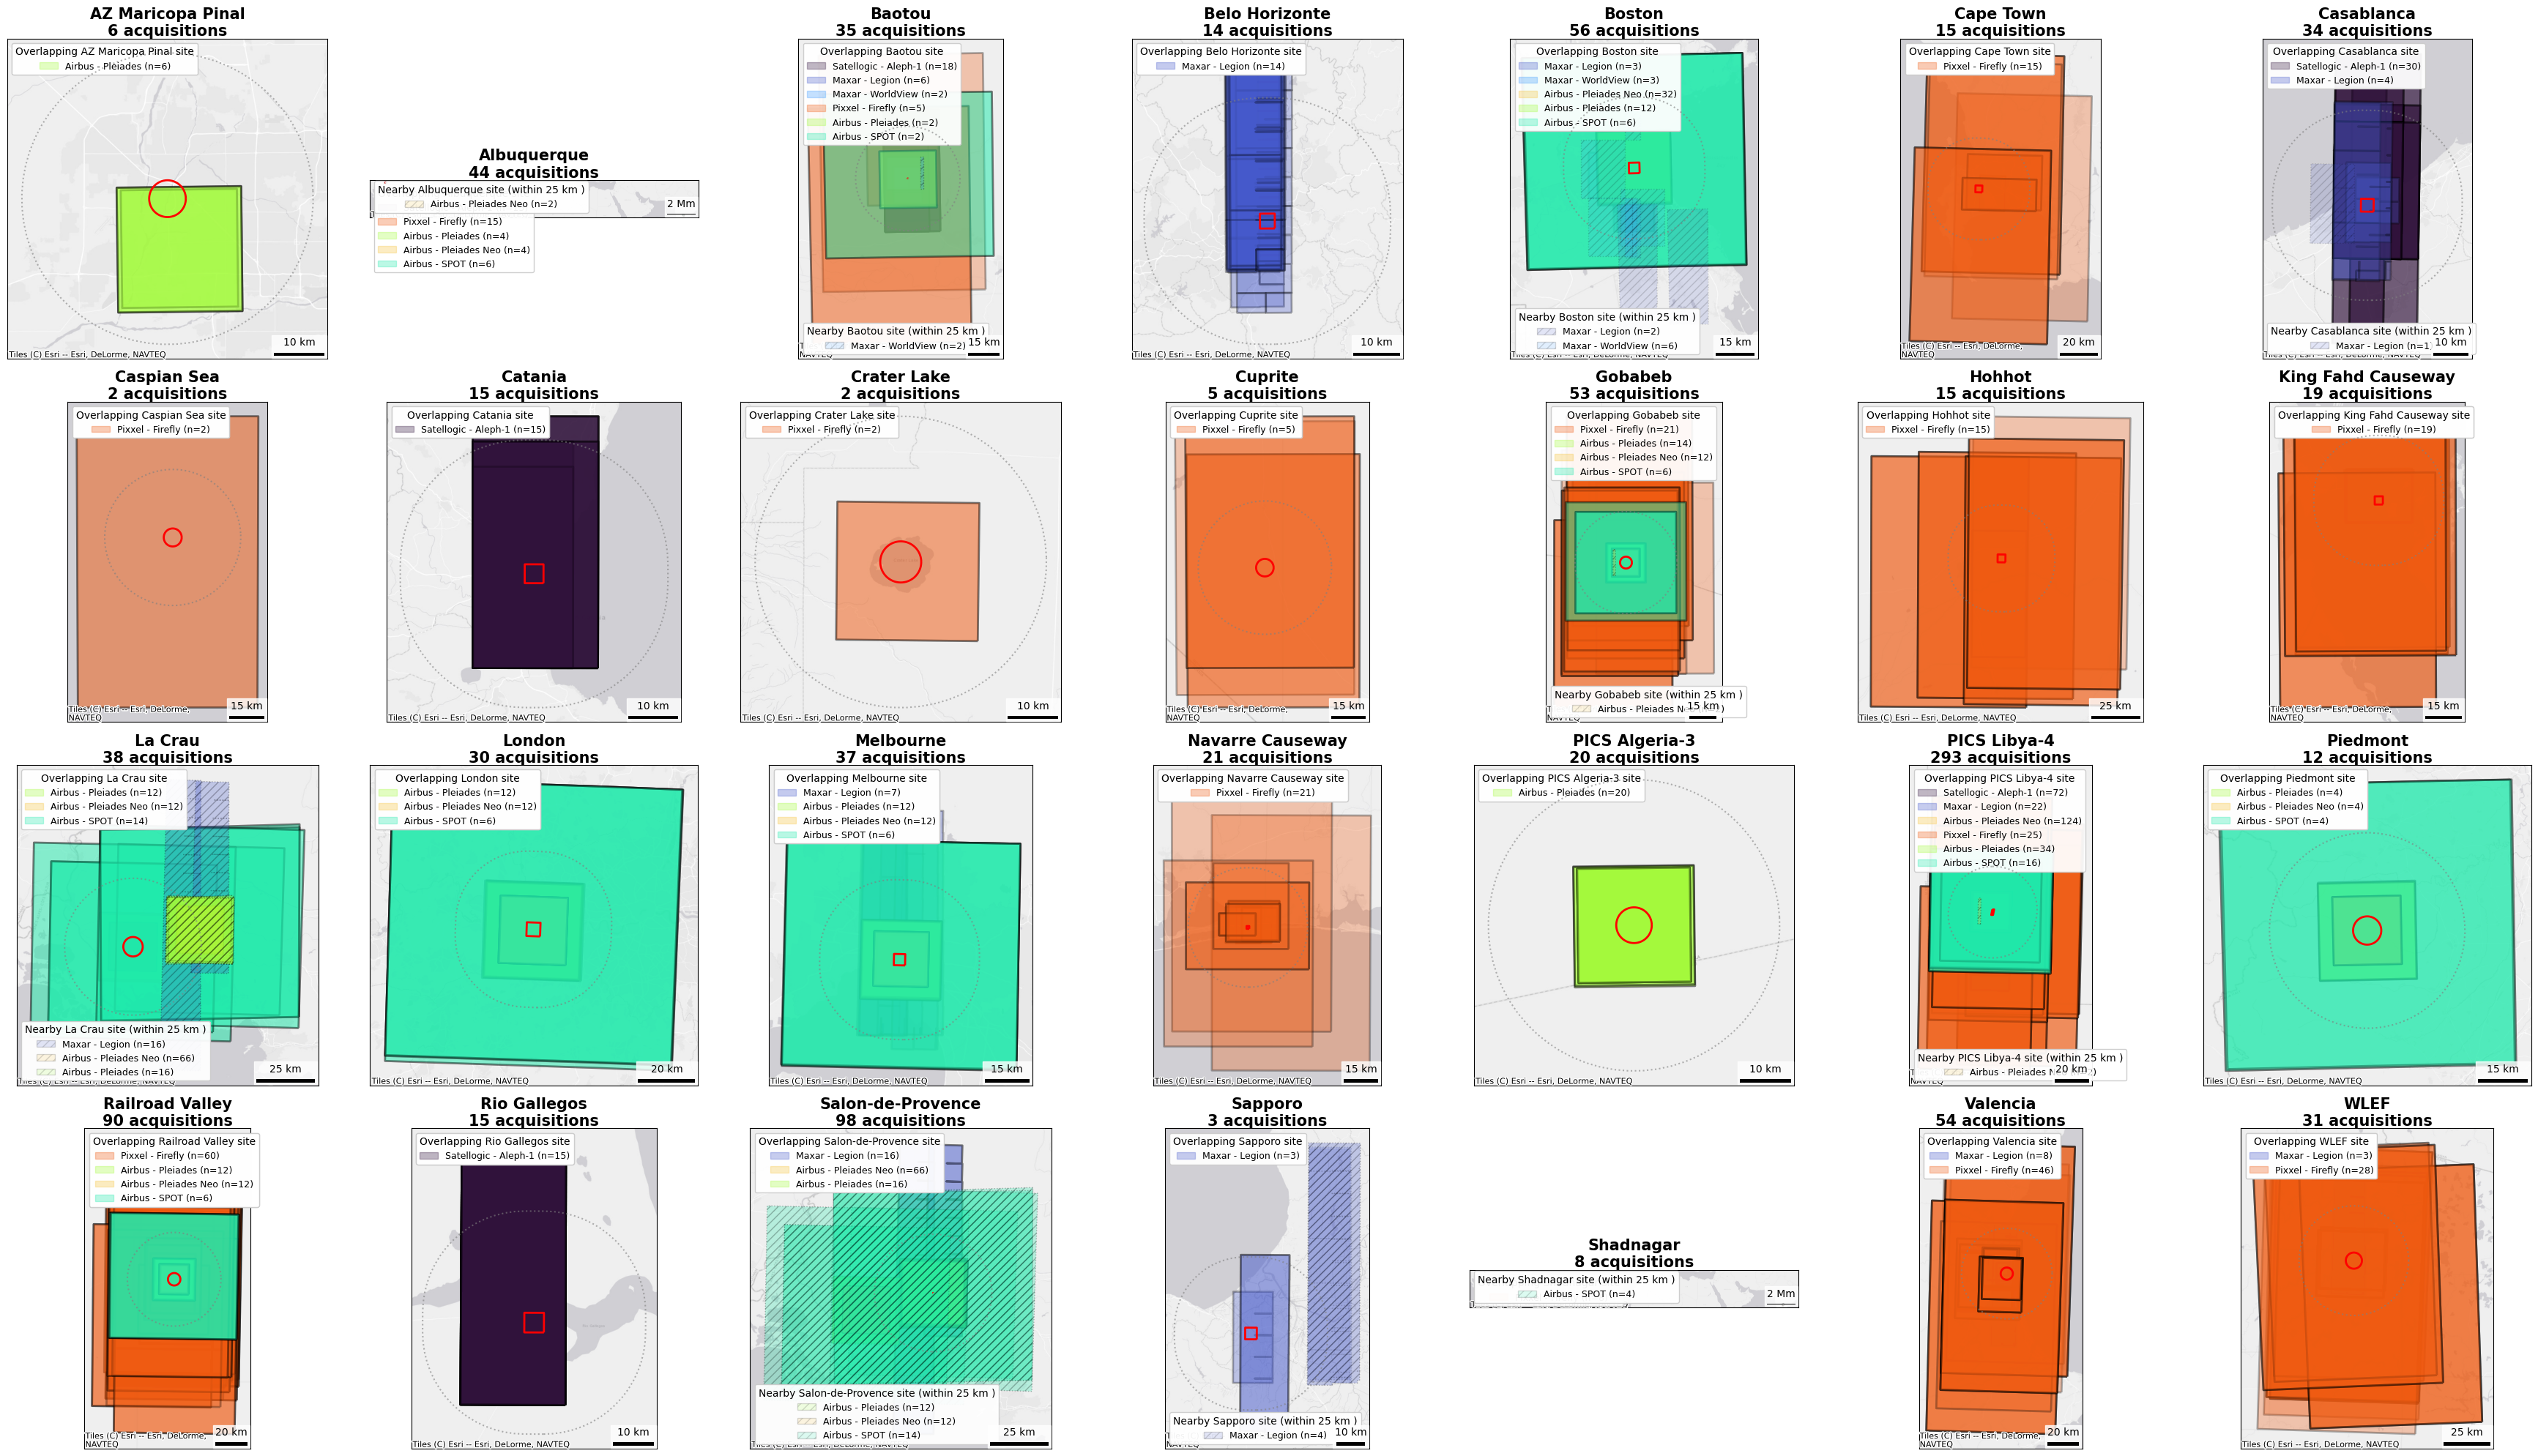

In [53]:
# Create grid
n_sites = len(sites_to_plot)
n_cols = 7
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot each site
for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(site_name, 
                      footprint_gdf_acquisitions_sites, 
                      sites_gdf, 
                      0, 
                       BUF_KM_TOTAL_FOR_DISPLAY,
                      sites_buf_gdf=sites_gdf_buf_display,
                      ax=axes[idx])  # Pass the axis here

# Hide unused subplots
for idx in range(n_sites, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [31]:
footprint_gdf_acquisitions_sites[
    (footprint_gdf_acquisitions_sites.Site_Primary == 'Baotou') &
    (footprint_gdf_acquisitions_sites.affiliation == 'Airbus') &
    (footprint_gdf_acquisitions_sites.image_type == 'MS')
]

,acquisition_id,geometry,base_image_name,path,sensor,affiliation,constellation,image_type,catid,date,...,month,day,scene_id,band_combo,file,Site_Primary,Site_Secondary,Site_Tertiary,num_sites,sites
839,PHR1B_202603160337039_ORT_7723902101-2,"POLYGON ((109.50999 40.80162, 109.50689 40.939...",PHR1B_MS_202603160337039_ORT_7723902101-2,/explore/nobackup/projects/CSDA_eval/Airbus/77...,PHR1B,Airbus,Pleiades,MS,DS_PHR1B_202603160336269_FR1_PX_E109N40_0821_0...,2026-03-16,...,3,16,"R2C1, R2C2, R1C1, R1C2",MS,4,Baotou,None,None,1,Baotou
1095,SPOT6_202601230308437_ORT_7674266101,"POLYGON ((109.27514 40.71040, 109.26431 41.125...",SPOT6_MS_202601230308437_ORT_7674266101,/explore/nobackup/projects/CSDA_eval/Airbus/PR...,SPOT6,Airbus,SPOT,MS,ORT_SPOT6_20260123_030844100_000,2026-01-23,...,1,23,"R2C1, R2C2, R1C1, R1C2",MS,4,Baotou,None,None,1,Baotou


In [32]:
footprint_gdf_acquisitions_sites[
    (footprint_gdf_acquisitions_sites.Site_Primary == 'PICS Libya-4') &
    (footprint_gdf_acquisitions_sites.affiliation == 'Airbus') &
    (footprint_gdf_acquisitions_sites.image_type == 'MS')
]

,acquisition_id,geometry,base_image_name,path,sensor,affiliation,constellation,image_type,catid,date,...,month,day,scene_id,band_combo,file,Site_Primary,Site_Secondary,Site_Tertiary,num_sites,sites
315,CCS_PNEO3_STD_202508220911077_FS_ORT_PWOI_0005...,"POLYGON ((23.46161 28.48360, 23.46464 28.61374...",CCS_PNEO3_STD_202508220911077_MS-FS_ORT_PWOI_0...,/explore/nobackup/projects/CSDA_eval/Airbus/Pl...,PNEO3,Airbus,Pleiades Neo,MS,202508220911077,2025-08-22,...,8,22,R1C1,MS,1,PICS Libya-4,None,None,1,PICS Libya-4
317,CCS_PNEO3_STD_202509120915091_FS_ORT_PWOI_0005...,"POLYGON ((23.46188 28.48359, 23.46491 28.61374...",CCS_PNEO3_STD_202509120915091_MS-FS_ORT_PWOI_0...,/explore/nobackup/projects/CSDA_eval/Airbus/Pl...,PNEO3,Airbus,Pleiades Neo,MS,202509120915091,2025-09-12,...,9,12,R1C1,MS,1,PICS Libya-4,None,None,1,PICS Libya-4
319,CCS_PNEO3_STD_202509170911076_FS_ORT_PWOI_0005...,"POLYGON ((23.46161 28.48360, 23.46464 28.61374...",CCS_PNEO3_STD_202509170911076_MS-FS_ORT_PWOI_0...,/explore/nobackup/projects/CSDA_eval/Airbus/Pl...,PNEO3,Airbus,Pleiades Neo,MS,202509170911076,2025-09-17,...,9,17,R1C1,MS,1,PICS Libya-4,None,None,1,PICS Libya-4
321,CCS_PNEO3_STD_202510080914431_FS_ORT_PWOI_0005...,"POLYGON ((23.46161 28.48360, 23.46464 28.61374...",CCS_PNEO3_STD_202510080914431_MS-FS_ORT_PWOI_0...,/explore/nobackup/projects/CSDA_eval/Airbus/Pl...,PNEO3,Airbus,Pleiades Neo,MS,202510080914431,2025-10-08,...,10,8,R1C1,MS,1,PICS Libya-4,None,None,1,PICS Libya-4
323,CCS_PNEO3_STD_202602250907500_FS_ORT_PWOI_0005...,"POLYGON ((23.46258 28.48358, 23.46561 28.61372...",CCS_PNEO3_STD_202602250907500_MS-FS_ORT_PWOI_0...,/explore/nobackup/projects/CSDA_eval/Airbus/Pl...,PNEO3,Airbus,Pleiades Neo,MS,202602250907500,2026-02-25,...,2,25,R1C1,MS,1,PICS Libya-4,None,None,1,PICS Libya-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068,SPOT6_202508160841036_ORT_7712774101,"POLYGON ((23.69825 28.28009, 23.53580 28.28320...",SPOT6_MS_202508160841036_ORT_7712774101,/explore/nobackup/projects/CSDA_eval/Airbus/SP...,SPOT6,Airbus,SPOT,MS,ORT_SPOT6_20250816_084103900_000,2025-08-16,...,8,16,"R2C1, R2C2, R1C1, R1C2",MS,4,PICS Libya-4,None,None,1,PICS Libya-4
1074,SPOT6_202508280848265_ORT_7514267101,"POLYGON ((23.64394 28.31428, 23.59308 28.31526...",SPOT6_MS_202508280848265_ORT_7514267101,/explore/nobackup/projects/CSDA_eval/Airbus/SP...,SPOT6,Airbus,SPOT,MS,ORT_SPOT6_20250828_084827400_000,2025-08-28,...,8,28,"R2C1, R2C2, R1C1, R1C2",MS,4,PICS Libya-4,None,None,1,PICS Libya-4
1075,SPOT6_202508280848265_ORT_7712775101,"POLYGON ((23.70155 28.27764, 23.53672 28.28081...",SPOT6_MS_202508280848265_ORT_7712775101,/explore/nobackup/projects/CSDA_eval/Airbus/SP...,SPOT6,Airbus,SPOT,MS,ORT_SPOT6_20250828_084826800_000,2025-08-28,...,8,28,"R2C1, R2C2, R1C1, R1C2",MS,4,PICS Libya-4,None,None,1,PICS Libya-4
1098,SPOT6_202602260846495_ORT_7705013101,"POLYGON ((23.70138 28.26363, 23.53541 28.26681...",SPOT6_MS_202602260846495_ORT_7705013101,/explore/nobackup/projects/CSDA_eval/Airbus/Re...,SPOT6,Airbus,SPOT,MS,ORT_SPOT6_20260226_084649700_000,2026-02-26,...,2,26,"R2C1, R2C2, R1C1, R1C2",MS,4,PICS Libya-4,None,None,1,PICS Libya-4


In [33]:
footprint_gdf_acquisitions_sites[
    (footprint_gdf_acquisitions_sites.Site_Primary == 'Boston') &
    (footprint_gdf_acquisitions_sites.constellation == 'Legion') &
    (footprint_gdf_acquisitions_sites.image_type == 'MS')
]

,acquisition_id,geometry,base_image_name,path,sensor,affiliation,constellation,image_type,catid,date,...,month,day,scene_id,band_combo,file,Site_Primary,Site_Secondary,Site_Tertiary,num_sites,sites
195,25APR09152934-M3DS_200012699716_01_P001,"POLYGON ((-71.07911 42.26455, -71.08100 42.321...",25APR09152934-M3DS-200012699716_01_P001,/explore/nobackup/projects/CSDA_eval/Maxar/Leg...,LG01,Maxar,Legion,MS,200012699716,2025-04-09,...,4,9,"R3C1, R2C2, R2C1, R3C2, R1C1, R1C2",,6,Boston,None,None,1,Boston
285,25SEP06153815-M3DS_200012699717_01_P001,"POLYGON ((-71.08252 42.31555, -71.08439 42.372...",25SEP06153815-M3DS-200012699717_01_P001,/explore/nobackup/projects/CSDA_eval/Maxar/Leg...,LG01,Maxar,Legion,MS,200012699717,2025-09-06,...,9,6,"R3C1, R2C1, R2C2, R4C1, R4C2, R3C2, R1C1, R1C2",,8,Boston,None,None,1,Boston
287,25SEP12123552-M3DS_200012699713_01_P001,"POLYGON ((-71.07063 42.26883, -71.07238 42.322...",25SEP12123552-M3DS-200012699713_01_P001,/explore/nobackup/projects/CSDA_eval/Maxar/Leg...,LG05,Maxar,Legion,MS,200012699713,2025-09-12,...,9,12,"R3C1, R2C2, R2C1, R4C1, R4C2, R3C2, R1C1, R5C2...",,10,Boston,None,None,1,Boston


In [34]:
footprint_gdf_acquisitions_sites.columns

Index(['acquisition_id', 'geometry', 'base_image_name', 'path', 'sensor',
       'affiliation', 'constellation', 'image_type', 'catid', 'date', 'year',
       'month', 'day', 'scene_id', 'band_combo', 'file', 'Site_Primary',
       'Site_Secondary', 'Site_Tertiary', 'num_sites', 'sites'],
      dtype='object')

In [35]:
failed_acquisitions_df.shape

(50, 6)

In [36]:
failed_scenes_df.shape

(50, 7)

## Create Comprehensive Summary of Multispectral Acquisitions

#### merging Acquisitions with Requested Acquisitions

how='left' (Recommended for most cases)  

+ Keeps all rows from summary_by_site (actual data you have)
+ Adds requested_acqs information where it matches
+ Use this if: You want to see all the data you actually collected, with requested acquisition counts added where available  
Result: Shows what you have, annotated with what was requested  

how='outer' (What you're currently using)  

+ Keeps all rows from both dataframes
+ Use this if: You want to see both what you collected AND what was requested (even if you didn't collect it)  
Result: Can show gaps - sites/sensors you were supposed to collect but didn't  

how='right'  

+ Keeps all rows from requested_acqs
+ Use this if: You only care about the requested combinations and want to see which ones you fulfilled  
Result: Only shows requested combinations, with actual data where available  

how='inner'  

+ Only keeps rows that match in both dataframes
+ Use this if: You only want to see requested combinations that you actually collected  
Result: Excludes both unrequested data you collected AND requested data you didn't collect  

In [37]:
requested_acqs[requested_acqs.Site == 'Baotou']

,affiliation,constellation,sensor,Site,Acquisitions Requested,Product,Request Date,Acquisition Date,Science Team Received
71,Maxar,Legion,LG01,Baotou,6,NaN,NaN,NaN,NaN


In [38]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [39]:
# Filter out panchromatic if needed
footprint_filtered_multispec = footprint_gdf_acquisitions_sites[footprint_gdf_acquisitions_sites.image_type != 'P']

# Step 2: Create comprehensive summaries
summaries = csdalib.create_comprehensive_summary(
    footprint_filtered_multispec,
    acq_site_mapping,
    site_name_col='Site_Primary',
    exclude_sites='Not CSDA Eval Site'
)

# Access different summaries:
site_summary            = summaries['by_site']  # Primary site assignments (no double counting)
sensor_summary          = summaries['by_sensor']  # Total by sensor
affiliation_summary     = summaries['by_affiliation']  # Total by affiliation
constellation_summary   = summaries['by_constellation']  # Total by constellation
multi_site              = summaries['multi_site_acquisitions']  # Acquisitions covering multiple sites
all_site_associations   = summaries['by_site_all_associations']  # All site-acquisition relationships

# Step 3: Merge with requested acquisitions
final_summary = pd.merge(
    #site_summary,
    site_summary.groupby(['Site_Primary','affiliation','constellation','sensor']).agg(sum).reset_index(),
    requested_acqs,
    left_on=['Site_Primary', 'affiliation', 'constellation', 'sensor'],
    right_on=['Site', 'affiliation', 'constellation', 'sensor'],
    how='outer'
)#.drop(columns=[
##    #'Site', 
#    'Affiliation', 'Constellation/Platform', 'Sensor/Generation'])

final_summary['acquisition_count'] = final_summary['acquisition_count'].fillna(0).astype(int)

final_summary['Acquisitions Requested'] = final_summary['Acquisitions Requested'].fillna(0).astype(int)
final_summary['Acquisitions Remaining'] = final_summary['Acquisitions Requested'] - final_summary['acquisition_count']
final_summary.loc[final_summary['Acquisitions Remaining'] < 0, 'Acquisitions Remaining'] = 0
out_csv_fn = f'/explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_summary_MS_{today_date_string}.csv'
print(f"Saving: {out_csv_fn}")
final_summary.to_csv(out_csv_fn)


Summary of acquisitions at CSDA Evaluation Sites
(excluding sites: Not CSDA Eval Site)
Total Affiliations:             4
Total Constellations:           7
Total Evaluation Sites:        28
Total Images:                 809
----------------------------------------------------------------------

Breakdown by Affiliation:
  Pixxel                  287 images
  Airbus                  286 images
  Satellogic              165 images
  Maxar                    71 images

Breakdown by Constellation:
  Pixxel/Firefly                           287 images
  Airbus/Pleiades Neo                      170 images
  Satellogic/Aleph-1                           165 images
  Airbus/Pleiades                           80 images
  Maxar/Legion                             66 images
  Airbus/SPOT                               36 images
  Maxar/WorldView                           5 images

Saving: /explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_summary_MS_2026-06-05.csv


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_608231/2148503429.py:23: FutureWarning: The operation <built-in function sum> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  site_summary.groupby(['Site_Primary','affiliation','constellation','sensor']).agg(sum).reset_index(),


In [40]:
final_summary

,Site_Primary,affiliation,constellation,sensor,acquisition_count,Site,Acquisitions Requested,Product,Request Date,Acquisition Date,Science Team Received,Acquisitions Remaining
0,AZ Maricopa Pinal,Airbus,Pleiades,PHR1A,3,NaN,0,NaN,NaN,NaN,NaN,0
1,Albuquerque,Airbus,Pleiades,PHR1A,2,NaN,0,NaN,NaN,NaN,NaN,0
2,Albuquerque,Airbus,Pleiades Neo,PNEO3,1,NaN,0,NaN,NaN,NaN,NaN,0
3,Albuquerque,Airbus,Pleiades Neo,PNEO4,1,NaN,0,NaN,NaN,NaN,NaN,0
4,Albuquerque,Airbus,SPOT,SPOT6,3,NaN,0,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
160,NaN,Pixxel,Firefly,FF01,0,Crater Lake,1,NaN,NaN,NaN,NaN,1
161,NaN,Pixxel,Firefly,FF01,0,Old Bahia Br,5,NaN,NaN,NaN,NaN,5
162,NaN,Maxar,Legion,LG01,0,WLEF,1,NaN,NaN,NaN,NaN,1
163,NaN,Maxar,Legion,LG01,0,Baotou,6,NaN,NaN,NaN,NaN,6


In [41]:
print(f"CSDA has data at n={len(site_summary[site_summary.Site_Primary != 'Not CSDA Eval Site'].Site_Primary.unique())} evaluation sites")

CSDA has data at n=28 evaluation sites


In [42]:
constellation_summary.total_acquisitions.sum()

809

In [43]:
final_summary['acquisition_count'].sum()

817

In [44]:
final_summary['Acquisitions Requested'].sum()

336

In [45]:
final_summary['Acquisitions Remaining'].sum()

115

#### Group using `Site` (not 'Site_Primary')

good for showing sites that dont yet have acqs

In [46]:
final_summary_sorted = final_summary\
.groupby(['affiliation', 'constellation','Site','sensor'])['acquisition_count','Acquisitions Requested','Acquisitions Remaining'].sum().reset_index()\
.sort_values(by='Acquisitions Remaining', ascending=False)

final_summary_sorted.to_csv(f'/explore/nobackup/projects/CSDA_eval/summaries/CSDA_eval_sites_footprint_summary_MS_sorted_{today_date_string}.csv')

final_summary_sorted.head()

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_608231/1664310792.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  final_summary_sorted = final_summary\


,affiliation,constellation,Site,sensor,acquisition_count,Acquisitions Requested,Acquisitions Remaining
73,Pixxel,Firefly,WLEF,FF01,0,20,20
69,Pixxel,Firefly,Railroad Valley,FF01,23,36,13
49,Maxar,Legion,Belo Horizonte,LG01,2,14,12
71,Pixxel,Firefly,Suramadu Bridge,FF01,0,9,9
48,Maxar,Legion,Baotou,LG01,0,6,6


#### Group using `Site_Primary` 

wont show summary for sites with 0 acqs so far..b/c they obs arent in the acqs gdf (which is where `Site_Primary` comes from)

In [47]:
tmp_smry = final_summary\
.groupby(['affiliation', 'constellation','Site_Primary','sensor'])['acquisition_count','Acquisitions Requested','Acquisitions Remaining'].sum().reset_index()\
.sort_values(by='Acquisitions Remaining', ascending=False)

tmp_smry[ (tmp_smry.Site_Primary == 'Baotou')]

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_608231/2153741093.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  tmp_smry = final_summary\


,affiliation,constellation,Site_Primary,sensor,acquisition_count,Acquisitions Requested,Acquisitions Remaining
90,Pixxel,Firefly,Baotou,FF03,2,0,0
89,Pixxel,Firefly,Baotou,FF02,3,0,0
84,Maxar,WorldView,Baotou,WV,2,0,0
128,Satellogic,Aleph-1,Baotou,SN50,3,0,0
127,Satellogic,Aleph-1,Baotou,SN48,3,0,0
126,Satellogic,Aleph-1,Baotou,SN43,3,0,0
123,Satellogic,Aleph-1,Baotou,SN27,3,0,0
124,Satellogic,Aleph-1,Baotou,SN31,3,0,0
125,Satellogic,Aleph-1,Baotou,SN41,3,0,0
2,Airbus,Pleiades,Baotou,PHR1B,1,0,0


In [48]:
tmp_smry = final_summary\
.groupby(['affiliation', 'constellation','Site_Primary','sensor'])['acquisition_count','Acquisitions Requested','Acquisitions Remaining'].sum().reset_index()\
.sort_values(by='Acquisitions Remaining', ascending=False)

tmp_smry[ (tmp_smry.Site_Primary == 'PICS Libya-4') & (tmp_smry.affiliation == 'Airbus')]

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_608231/1660397448.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  tmp_smry = final_summary\


,affiliation,constellation,Site_Primary,sensor,acquisition_count,Acquisitions Requested,Acquisitions Remaining
35,Airbus,Pleiades Neo,PICS Libya-4,PNEO3,34,4,0
16,Airbus,Pleiades,PICS Libya-4,PHR1B,8,4,0
15,Airbus,Pleiades,PICS Libya-4,PHR1A,9,4,0
36,Airbus,Pleiades Neo,PICS Libya-4,PNEO4,28,4,0
50,Airbus,SPOT,PICS Libya-4,SPOT6,8,3,0


## Create `latest` footprint `gpkg` and summary `csv` files

In [49]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

In [50]:
import os
import glob

# Usage example:
dir_list = ['/explore/nobackup/projects/CSDA_eval/summaries',
            '/explore/nobackup/projects/CSDA_eval/footprints'
           ]

for directory in dir_list:
    # Delete existing *_latest.csv and *_latest.gpkg files
    for ext in ['csv', 'gpkg']:
        latest_pattern = os.path.join(directory, f'*_latest.{ext}')
        existing_latest = glob.glob(latest_pattern)
        for file in existing_latest:
            try:
                os.remove(file)
                print(f"Deleted existing file: {os.path.basename(file)}")
            except Exception as e:
                print(f"Warning: Could not delete {file}: {e}")
    
    # Now copy the latest files
    latest_files = csdalib.copy_all_latest_files(directory, extensions=['csv', 'gpkg'])

    cmd = f'chmod -R 755 {directory}'
    print(f'\n\tOpening up access with chmod: {cmd}')
    !eval $cmd
    
    # Show results
    print("\n=== Summary ===")
    for key, filepath in latest_files.items():
        print(f"{key}: {os.path.basename(filepath)}")

Deleted existing file: CSDA_eval_sites_footprint_summarypivot_MS_latest.csv
Deleted existing file: CSDA_eval_sites_footprint_summary_MS_latest.csv
Deleted existing file: CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv
Found 44 dated files

=== Processing files ===
  Copied: CSDA_eval_sites_footprint_summary_MS_2026-06-05.csv -> CSDA_eval_sites_footprint_summary_MS_latest.csv (date: 2026-06-05)
  Copied: CSDA_eval_sites_footprint_summary_MS_sorted_2026-06-05.csv -> CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv (date: 2026-06-05)
  Copied: CSDA_eval_sites_footprint_summarypivot_MS_2026-02-12.csv -> CSDA_eval_sites_footprint_summarypivot_MS_latest.csv (date: 2026-02-12)

	Opening up access with chmod: chmod -R 755 /explore/nobackup/projects/CSDA_eval/summaries

=== Summary ===
CSDA_eval_sites_footprint_summary_MS.csv: CSDA_eval_sites_footprint_summary_MS_latest.csv
CSDA_eval_sites_footprint_summary_MS_sorted.csv: CSDA_eval_sites_footprint_summary_MS_sorted_latest.csv
CSDA_

In [51]:
len(footprint_gdf.acquisition_id.unique())

1136

In [52]:
len(footprint_gdf.cleaned_filename.unique())

4043

#### Read, plot (draft)

In [ ]:
START_HERE = False

In [ ]:
if START_HERE:
    footprint_gdf_acquisitions_sites = gpd.read_file(footprint_ACQS_gdf_FN.replace(today_date_string, 'latest'))
    footprint_gdf = gpd.read_file(footprint_gdf_FN.replace(today_date_string, 'latest'))

In [ ]:
importlib.reload(csdalib)

### Plot tasking order acquisition timeline with footprint

In [ ]:
# # Something wrong with timeline ticks - fix this
# fig, ax = csdalib.plot_acquisition_timeline_gantt(footprint_gdf_acquisitions_sites)
# plt.show()

# Heatmap
fig, ax = csdalib.plot_acquisition_heatmap(footprint_gdf_acquisitions_sites)
plt.show()